In [73]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Set Dataset Paths

In [74]:
train_dir = "/kaggle/input/datasets/mrkk8565/ship-classification/FGSC-23/train"
test_dir = "/kaggle/input/datasets/mrkk8565/ship-classification/FGSC-23/test"

Load Dataset

In [75]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.3],
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_data.num_classes
print("Number of classes:", num_classes)

Found 2614 images belonging to 23 classes.
Found 642 images belonging to 23 classes.
Found 824 images belonging to 23 classes.
Number of classes: 23


Function to Create CNN Models

In [76]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_classes = 23  # Make sure this is defined before the function

def create_model(model_name, input_shape=(224,224,3)):

    # Load base model
    if model_name == "VGG16":
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == "MobileNetV2":
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported model name")

    # Freeze early layers, allow last 30 to train
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Build classifier on top
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.00005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

Train the 3 CNN Models

In [78]:
models_to_run = ["VGG16","ResNet50","MobileNetV2"]

trained_models = {}
trained_histories = {}

for model_name in models_to_run:

    print("\nTraining", model_name)

    model = create_model(model_name)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=20,
        callbacks=[early_stop] 
    )

    trained_models[model_name] = model
    trained_histories[model_name] = history


Training VGG16


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 765ms/step - accuracy: 0.0569 - loss: 3.2274 - val_accuracy: 0.1199 - val_loss: 3.0478
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 54s 656ms/step - accuracy: 0.1526 - loss: 2.9533 - val_accuracy: 0.2025 - val_loss: 3.0850
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 54s 649ms/step - accuracy: 0.2190 - loss: 2.6794 - val_accuracy: 0.1698 - val_loss: 3.7117
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 643ms/step - accuracy: 0.2316 - loss: 2.5160 - val_accuracy: 0.2118 - val_loss: 2.7763
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 665ms/step - accuracy: 0.2724 - loss: 2.3392 - val_accuracy: 0.2165 - val_loss: 2.6217
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 666ms/step - accuracy: 0.3001 - loss: 2.2003 - val_accuracy: 0.3224 - val_loss: 2.1481
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 678ms/step - accuracy: 0.3717 - loss: 1.9876 - val_accuracy: 0.3567 - val_loss: 2.1153
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 670ms/step - accuracy: 0.4071 - loss: 1.8231 - val_accu

Plot Training & Validation Accuracy/Loss

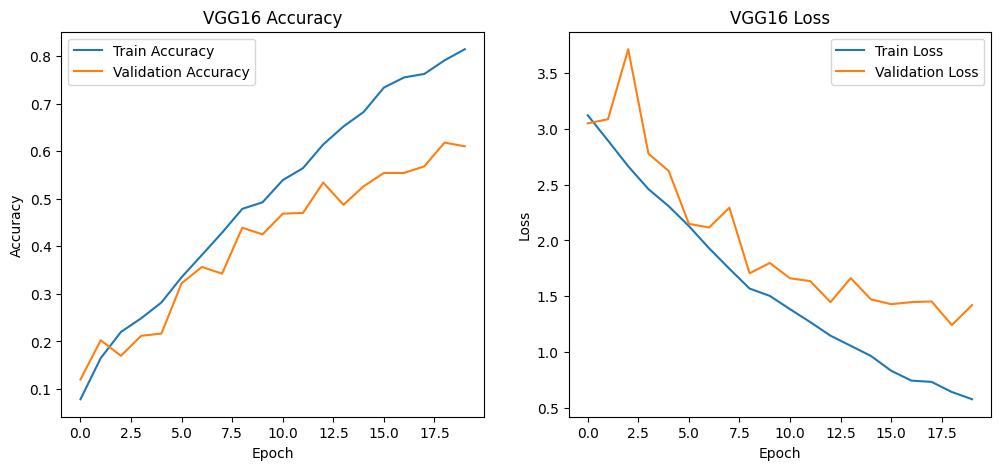

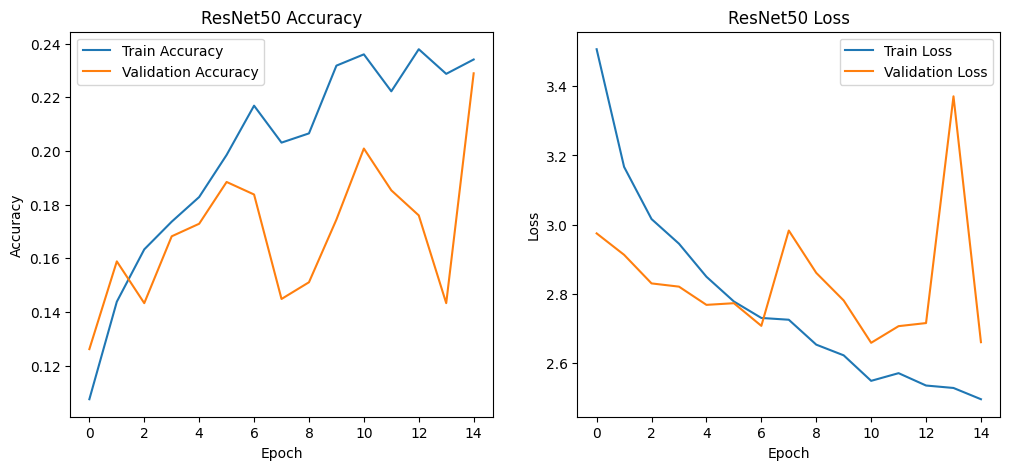

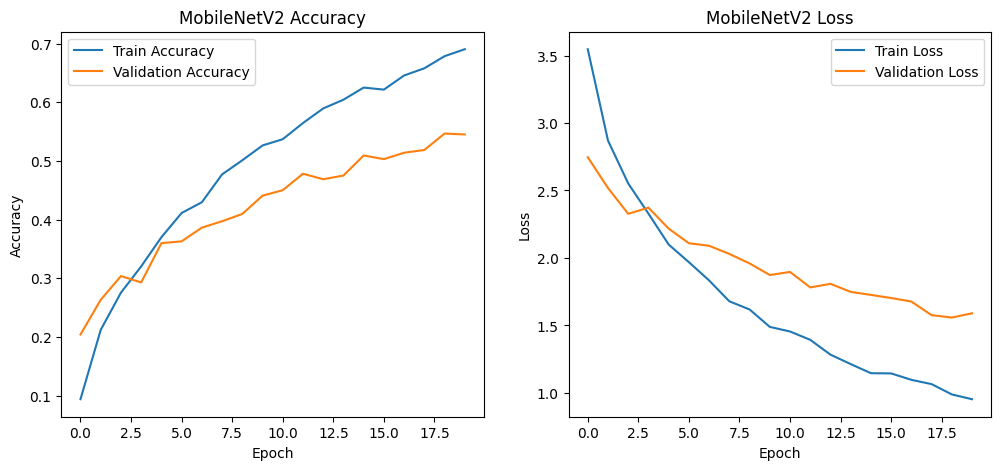

In [79]:
def plot_training_history(history, model_name):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train Accuracy")
    plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(model_name + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


for model_name, history in trained_histories.items():
    plot_training_history(history, model_name)

Evaluate Models (Accuracy, Precision, Recall)

In [80]:
for model_name, model in trained_models.items():

    print("\nEvaluating", model_name)

    preds = model.predict(test_data)
    pred_classes = np.argmax(preds, axis=1)

    true_classes = test_data.classes

    print("Accuracy:", accuracy_score(true_classes, pred_classes))

    print("\nClassification Report:")
    print(classification_report(true_classes, pred_classes))


Evaluating VGG16
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step
Accuracy: 0.6601941747572816

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        97
           1       0.76      0.56      0.64        34
           2       0.74      0.81      0.77        48
           3       1.00      0.10      0.18        10
           4       0.91      0.72      0.81        29
           5       0.52      0.31      0.39        45
           6       0.89      0.84      0.86        19
           7       0.80      0.86      0.83        14
           8       0.83      1.00      0.91        24
           9       0.70      0.68      0.69        69
          10       0.54      0.82      0.65        33
          11       0.53      0.45      0.49        20
          12       0.67      0.72      0.70       108
          13       0.86      0.33      0.48        18
          14       1.00      0.85      0.92        20
          15       0.71

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 280ms/step
Accuracy: 0.6067961165048543

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.81      0.68        97
           1       0.88      0.65      0.75        34
           2       0.71      0.67      0.69        48
           3       1.00      0.20      0.33        10
           4       0.54      0.72      0.62        29
           5       0.57      0.36      0.44        45
           6       0.92      0.63      0.75        19
           7       0.85      0.79      0.81        14
           8       0.77      0.96      0.85        24
           9       0.79      0.54      0.64        69
          10       0.78      0.55      0.64        33
          11       0.41      0.45      0.43        20
          12       0.57      0.74      0.64       108
          13       0.80      0.22      0.35        18
          14       1.00      0.95      0.97        20
          15       0.75      0.82      0

Confusion Matrix

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step


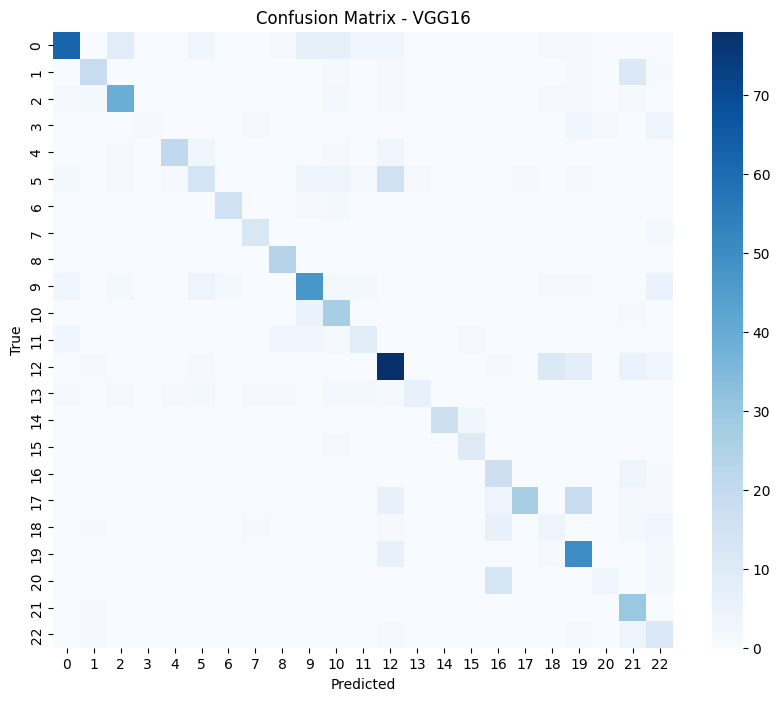

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step


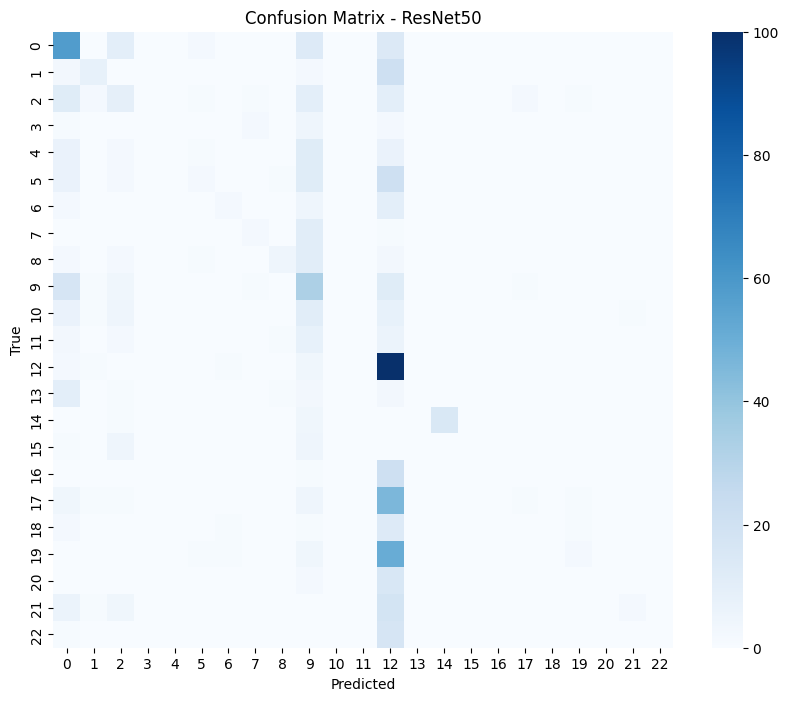

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


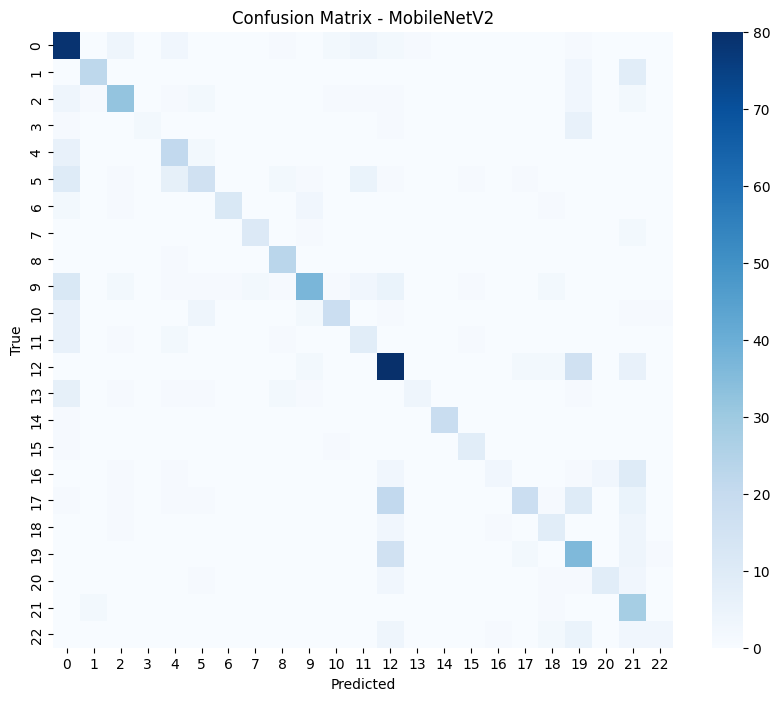

In [81]:
for model_name, model in trained_models.items():

    preds = model.predict(test_data)
    pred_classes = np.argmax(preds, axis=1)

    cm = confusion_matrix(test_data.classes, pred_classes)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues")
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()